<a href="https://colab.research.google.com/github/seom0323-web/Computational-Physics-Newman/blob/main/ComputationalPhysics(ODE3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

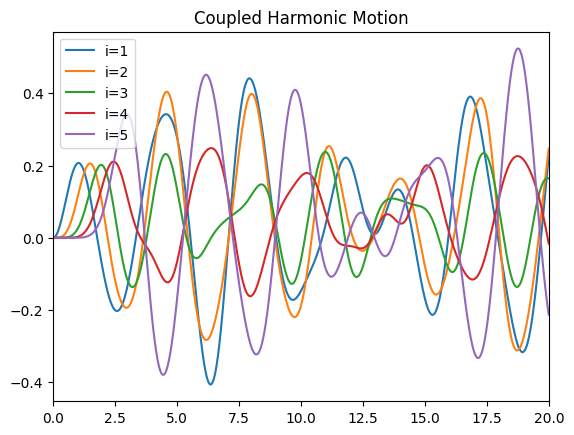

In [2]:
#연성진동(룽게 쿠타)
import numpy as np
import matplotlib.pyplot as plt

def f(k,N,r,t): #연성진동 미분방정식
  x, dx=r[:N], r[N:] #위치와 속도
  dv=[0 for _ in range(0,N)] #미분방정식
  if N==0:
    dv[0]=cos(2*t)
  elif N==1:
    dv[1]=cos(2*t)
  elif N==2:
    dv[0]=k*(x[1]-x[0])+np.cos(2*t)
    dv[1]=k*(x[0]-x[1])
  else:
    dv[0]=k*(x[1]-x[0])+np.cos(2*t)
    for i in range(1,N-1):
      dv[i]=k*(x[i+1]-x[i])+k*(x[i-1]-x[i])
    dv[N-1]=k*(x[N-2]-x[N-1])
  return np.array(list(dx)+dv,float)


a=0.0
b=20.0
n=1000
h=(b-a)/n
k=6 #용수철 상수
N=5 #입자의 개수
t=np.arange(a,b,h)

r=np.zeros((len(t),2*N),float)

for i in range(0,len(t)-1): #룽게쿠타 방법
  k1=h*f(k,N,r[i],t[i])
  k2=h*f(k,N,r[i]+0.5*k1,t[i]+0.5*h)
  k3=h*f(k,N,r[i]+0.5*k2,t[i]+0.5*h)
  k4=h*f(k,N,r[i]+k3,t[i]+h)
  r[i+1]=r[i]+(k1+2*k2+2*k3+k4)/6

for j in range(0,N):
  plt.plot(t,r[:,j],label=f'i={j+1}')
plt.title(f'Coupled Harmonic Motion')
plt.legend()
plt.xlim(0,20)
plt.show()








In [4]:
from IPython.display import HTML
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import numpy as np

# 1. 작성한 코드의 결과 데이터 매핑
# r[:, :N]에 각 입자의 변위(x)가 들어있음
displacement_data = r[:, :N]  # shape: (len(t), 5)
N_steps = len(t)

# 2. 입자 평형 위치 설정 (간격 d)
d = 2.0
x_eq = np.array([(j + 1) * d for j in range(N)])

# 양쪽 경계 설정
# (dv[N-1]에 오른쪽 벽 연결 항이 없으므로 자유단 또는 충분한 여백으로 설정)
left_wall = 0.0
right_limit = (N + 2) * d

# 3. 플롯 초기화
fig, ax = plt.subplots(figsize=(9, 2.5))
ax.set_xlim(-0.5, right_limit)
ax.set_ylim(-1.0, 1.0)
ax.set_yticks([])
ax.set_xlabel("x position")
ax.set_title("Coupled Harmonic Motion (Forced Oscillation)")

# 좌측 고정벽
ax.axvline(left_wall, color="black", lw=3)

# 입자들
(scatter,) = ax.plot(
    [],
    [],
    "o",
    color="crimson",
    markersize=12,
    markeredgecolor="black",
    zorder=3,
)

# 입자 사이 연결선 (스프링)
(spring_lines,) = ax.plot([], [], "-", color="gray", lw=1.5, zorder=2)


# 4. 프레임 갱신 함수
def update(frame):
  # frame 번째 스텝의 5개 입자 위치
  current_pos = x_eq + displacement_data[frame]

  # 구 위치 업데이트
  scatter.set_data(current_pos, np.zeros(N))

  # 좌측 벽부터 마지막 입자까지 선 연결
  chain_x = np.concatenate([[left_wall], current_pos])
  chain_y = np.zeros(len(chain_x))
  spring_lines.set_data(chain_x, chain_y)

  return scatter, spring_lines


# 5. 애니메이션 렌더링 (step_skip으로 부드러움과 렌더링 속도 조절)
step_skip = 2
frames_to_play = range(0, N_steps, step_skip)

ani = animation.FuncAnimation(
    fig, update, frames=frames_to_play, interval=25, blit=True
)
plt.close(fig)

HTML(ani.to_jshtml())
ani.save('Coupled Harmonic Motion.mp4', fps=60, writer='ffmpeg')